# Trajectory Inference: Shaped Double Launch (RID 74108)

Simulation-based trajectory inference for the `LMTInterferometryWithShapedDoubleLaunch` pulse sequence, extracted from ARTIQ run **RID 74108** (2026-06-10). Built from the `true_trajectory_double_launch.ipynb` template.

In [1]:
# Add auto reload:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
from scipy import constants as scipy_constants
import version_info as vs

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator

In [3]:
# RID74305
pulse_sequence = [[[1,0,1,0,1,0,1,0,1,0,1,0,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0],[4936,2690399,2736543,2945087,3025086,3092085,3172084,3239083,3319082,3386081,3466080,3533079,3613078,8180077,8297092,8377091,8494106,8574105,8691120,8771119,8888134,8968133,9085148,9165147,9282162,9367343,9603871],[380000,34000,199999,68000,54999,68000,54999,68000,54999,68000,54999,68000,54999,54999,68000,54999,68000,54999,68000,54999,68000,54999,68000,54999,68000,30555,68000],[80000000,79971625,80032357,79986849,80004873,80003585,79988137,80020321,79971401,80037057,79954665,80053793,79937929,80114853,79892903,80098819,79908937,80082785,79924971,80066752,79941004,80050718,79957038,80034684,79973072,80018869,79987355],[200000000,200005800,200000000,200005800,200001500,200005800,200001500,200005800,200001500,200005800,200001500,200005800,200001500,200001500,200005800,200001500,200005800,200001500,200005800,200001500,200005800,200001500,200005800,200001500,200005800,200000500,200005800],[99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500],[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2]],[[1,0,1,0,1,0,1,0,1,0,1,0,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0],[4936,2690399,2736543,2945087,3025086,3092085,3172084,3239083,3319082,3386081,3466080,3533079,3613078,8180077,8297092,8377091,8494106,8574105,8691120,8771119,8888134,8968133,9085148,9165147,9282162,9367343,9603871],[380000,34000,199999,68000,54999,68000,54999,68000,54999,68000,54999,68000,54999,54999,68000,54999,68000,54999,68000,54999,68000,54999,68000,54999,68000,30555,68000],[80000000,79971625,80032357,79986849,80004873,80003585,79988137,80020321,79971401,80037057,79954665,80053793,79937929,80114853,79892903,80098819,79908937,80082785,79924971,80066752,79941004,80050718,79957038,80034684,79973072,80018869,79987355],[200000500,200005800,200000000,200005800,200001500,200005800,200001500,200005800,200001500,200005800,200001500,200005800,200001500,200001500,200005800,200001500,200005800,200001500,200005800,200001500,200005800,200001500,200005800,200001500,200005800,200000500,200005800],[99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500,99473500],[2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2]],[[-1]],[[-1]],[[-1]],[[-1]],[[-1]],[[-1]],[[-1]]]

In [4]:
# The recorded dump above uses the legacy nested layout with its two time rows
# in machine units. Re-encode it into the new float64 SI pulse_record_flat /
# pulse_record_offsets datasets -- the format now emitted by PulseDMARecording
# in icl_experiments -- and decode it with the shared decoder so this notebook
# exercises the same code path as real archived data. 1 machine unit = 1 ns.
def _legacy_record_to_flat_si(record):
    directions, start_mu, dur_mu, opll, switch, delivery, setpoint = record
    rows = [
        np.asarray(directions, dtype=float),
        np.asarray(start_mu, dtype=float) * 1e-9,
        np.asarray(dur_mu, dtype=float) * 1e-9,
        np.asarray(opll, dtype=float),
        np.asarray(switch, dtype=float),
        np.asarray(delivery, dtype=float),
        np.asarray(setpoint, dtype=float),
    ]
    return np.concatenate([[float(len(directions))]] + rows)


pulse_record_flat = _legacy_record_to_flat_si(pulse_sequence[0])
pulse_record_offsets = np.array([0], dtype=np.int64)

dump = seq.decode_pulse_record_flat(pulse_record_flat, pulse_record_offsets)[0]
is_up = dump.is_up
start_times_s = dump.start_times_s
durations_s = dump.durations_s
opll_hz = dump.opll_hz
switch_hz = dump.switch_hz
delivery_hz = dump.delivery_hz
delivery_setpoint = dump.delivery_setpoint

# --- Correct the recorded shelving-pulse OPLL to its pulse-centre value ---
# This dump predates centre-of-pulse reporting in the lab's pulse recorder
# (PulseDMARecording.register_pulse in icl_experiments now records the OPLL
# frequency averaged over the pulse). The 380 us velocity-selection pulse
# fires while the clock OPLL is ramping at the gravity rate (clock_shelving.py
# starts the DRG ramp immediately before it), so the recorded START value is
# below the pulse-centre value by ramp_rate * duration / 2 ~ 2.7 kHz
# (0.57 recoil). The LMT pi pulses are fired with a STATIC OPLL
# (LMT_launch_mixins.fire_lmt_pulse) and need no correction.
opll_hz = opll_hz.astype(float)
opll_hz[0] += sim.GRAVITY_DOPPLER_PER_SEC_HZ * durations_s[0] / 2

In [5]:
# Manually specify which durations are pi pulses and which are pi/2
is_pi_pulse = lambda d: d > 50000e-9

In [6]:
# # Cut after the launch

# t_launch_finished = 5e-3

# is_before_launch = start_times_s < t_launch_finished

# is_up = is_up[is_before_launch]
# start_times_s = start_times_s[is_before_launch]
# durations_s = durations_s[is_before_launch]
# opll_hz = opll_hz[is_before_launch]
# switch_hz = switch_hz[is_before_launch]
# delivery_hz = delivery_hz[is_before_launch]
# delivery_setpoint = delivery_setpoint[is_before_launch]

In [7]:
len(is_up)

27

In [8]:
# --- HACKY AUTO-CALIBRATION (a warning is emitted at runtime) ---
# alpha (probe-shift coefficient) and v0 (initial atom velocity) used to be
# hand-tuned magic numbers. Instead we now back them out of the lab pulse dump:
# alpha from how the up-beam pulses sit relative to each other vs their Rabi
# frequency, and v0 from the residual up/down detuning once alpha is applied.
# This is a self-consistent fit, NOT a measurement -- replace with real
# light-shift and launch-velocity calibrations.
# probe_shift_alpha, initial_velocity_z = (
#     seq.calibrate_probe_shift_and_velocity_from_dump(
#         is_up=is_up,
#         start_times_s=start_times_s,
#         durations_s=durations_s,
#         opll_hz=opll_hz,
#         switch_hz=switch_hz,
#         delivery_hz=delivery_hz,
#         delivery_setpoint=delivery_setpoint,
#     )
# )


t_pi_ref = 55e-6


# From measurement - see "2026-06-09 Clock shift gap-filling even Omega2 grid"
# The measurement defined alpha in terms of 1/ (rad/s), so convert to 1/Hz
probe_shift_alpha = -2.04e-6 * (2 * np.pi)
print(f"calibrated probe-shift alpha = {probe_shift_alpha:.4e} Hz^-1")

rabi_freq_ref = 1 / (2*t_pi_ref)
probe_shift_ref = probe_shift_alpha * rabi_freq_ref**2
print(f"corresponding probe shift at Rabi frequency {rabi_freq_ref:.1f} Hz is {probe_shift_ref:.1f} Hz")


calibrated probe-shift alpha = -1.2818e-05 Hz^-1
corresponding probe shift at Rabi frequency 9090.9 Hz is -1059.3 Hz


In [9]:
# Pin initial_velocity_z so the first DOWN pulse is resonant on its intended
# rung. The parser anchors everything on the first (up) pulse, so the only
# leftover beam-asymmetric term is the 2*v0/lambda Doppler split between the
# counter-propagating beams. Same logic as
# seq.calibrate_probe_shift_and_velocity_from_dump, but holding alpha at the
# measured value above instead of fitting it. (Replaces an old hand-tuned
# FIXME value.)

# N.B. the lab bakes small software detunings into some pulses (e.g.
# double_trap_launch_bs_detuning, lmt_launch_offset_detuning, the up/down
# switch offsets in icl_experiments). These compensate REAL effects in the
# lab -- the recorded frequencies are what was actually resonant -- but the
# compensated effects (e.g. intensity-dependent light shifts beyond the
# alpha*rabi**2 model used here) are not all in the simulation, so this
# pinning absorbs any model mismatch into initial_velocity_z
# (1 kHz <-> 0.35 mm/s).
timestamps, _bare = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_s=start_times_s,
    durations_s=durations_s,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    probe_induced_alpha_up=0.0,
    probe_induced_alpha_down=0.0,
    initial_velocity_z=0.0,
)
_pulses = [e for e in _bare if isinstance(e, seq.Pulse)]
_anchor = _pulses[0]
_first_opposite = next(p for p in _pulses if p.k == -_anchor.k)
_anchor_rabi = _anchor.rabi_frequency
initial_velocity_z = (
    _anchor.k
    * 0.5
    * sim.TRANSITION_WAVELENGTH
    * (
        _anchor.detuning_hz
        - _first_opposite.detuning_hz
        - 4 * sim.RECOIL_FREQUENCY_HZ
        - probe_shift_alpha
        * (_anchor_rabi**2 - _first_opposite.rabi_frequency**2)
    )
)
print(f"initial_velocity_z = {initial_velocity_z * 1e3:+.3f} mm/s")

initial_velocity_z = -1.384 mm/s


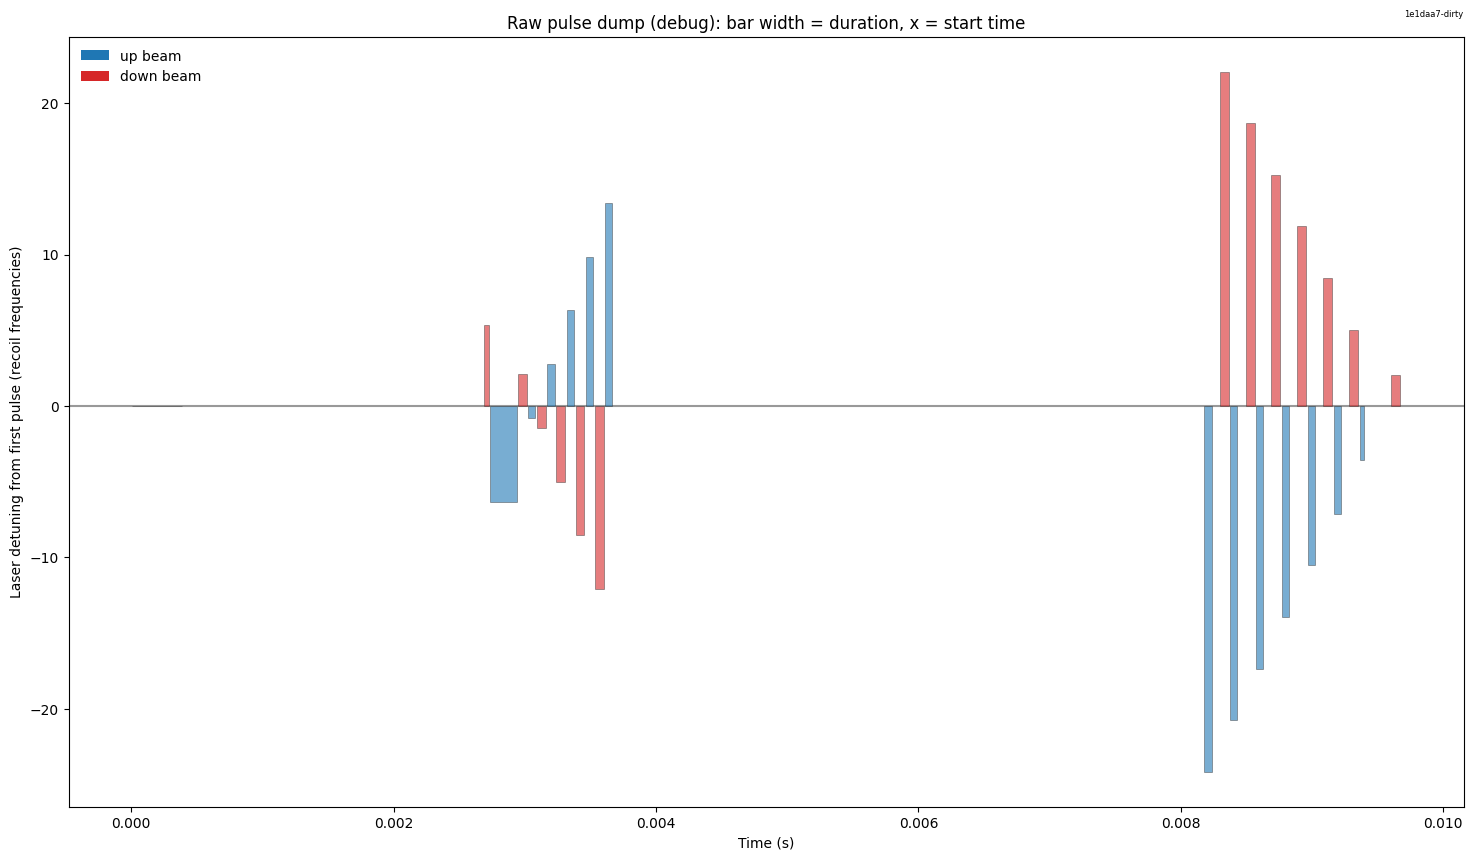

In [10]:
# --- DEBUG: raw pulse dump. Each recorded pulse is a bar at its true start time
# with WIDTH = duration, so overlapping pulses are visible. No gravity/Doppler
# compensation and no pi-pulse identification -- just the raw pulses, coloured by
# up/down beam.

_t = start_times_s
_dur = durations_s
_isup = is_up.astype(bool)

# Lab-frame laser detuning recentred on the first pulse (a constant offset --
# NOT gravity/Doppler compensation), just so the y-axis is legible in recoil
# units instead of spanning hundreds of MHz.
_detuning_recoil = (
    (-opll_hz - switch_hz - delivery_hz)
    - (-opll_hz[0] - switch_hz[0] - delivery_hz[0])
) / sim.RECOIL_FREQUENCY_HZ

fig, ax = plt.subplots(figsize=(18, 10))
for _s, _w, _y, _up in zip(_t, _dur, _detuning_recoil, _isup):
    ax.bar(
        _s, _y, width=_w, align="edge",
        color="tab:blue" if _up else "tab:red",
        alpha=0.6, edgecolor="0.2", linewidth=0.5, zorder=2,
    )
ax.axhline(0.0, color="0.5", linestyle="-", alpha=0.8, zorder=0)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Laser detuning from first pulse (recoil frequencies)")
ax.set_title("Raw pulse dump (debug): bar width = duration, x = start time")
ax.legend(
    handles=[
        Patch(facecolor="tab:blue", label="up beam"),
        Patch(facecolor="tab:red", label="down beam"),
    ],
    loc="upper left",
    frameon=False,
)
vs.tag_plot(small=True);

In [11]:
_, sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_s=start_times_s,
    durations_s=durations_s,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=initial_velocity_z,
    probe_induced_alpha_up=probe_shift_alpha,
    probe_induced_alpha_down=probe_shift_alpha,
)


## The velocity-selection pulse needs no Stark marking

The first pulse (380 us, up beam) is a shaped ("Jesse") velocity-selection pulse:
phase-modulated at constant full DDS amplitude. Crucially, though, it is fired with
the clock delivery servo at a LOW dedicated setpoint
(`shelving_clock_delivery_setpoint` in icl_experiments) -- much lower intensity than
the LMT pulses. That is why it is long: low Rabi frequency, narrow Fourier linewidth
for velocity selection. Its duration-implied Rabi (`1/(2 * 380 us)` ~ 1.3 kHz) is
therefore approximately its TRUE Rabi frequency, and its probe-induced Stark shift is
correspondingly small (~ -22 Hz). The parser's default treatment is correct and no
`stark_rabi_frequency` marking is needed.

(An earlier version of this notebook marked this pulse with the LMT pulses' 9.1 kHz
Rabi. That was wrong: only the 200 us shaped LMT pulse below runs at high intensity.)

N.B. the dump records a per-pulse `delivery_setpoint` which would settle intensity
questions directly, but it currently reads 2.000 for every pulse including this one --
a pulse-recorder bug, to be fixed in icl_experiments. The simulation does not use it.

In [12]:
from collections import Counter

pulses = [e for e in sequence if isinstance(e, seq.Pulse)]

rabi_counts = Counter(p.rabi_frequency for p in pulses[1:] if p.k == +1)
print("Rabi frequencies inferred for the up pulses after the VS pulse:")
for rabi, count in sorted(rabi_counts.items()):
    print(f"  {rabi:8.1f} Hz x {count}")
lmt_up_rabi = rabi_counts.most_common(1)[0][0]
print(f"-> LMT pi-pulse Rabi frequency: {lmt_up_rabi:.1f} Hz")
assert np.isclose(lmt_up_rabi, rabi_freq_ref, rtol=1e-3)

Rabi frequencies inferred for the up pulses after the VS pulse:
    2500.0 Hz x 1
    8182.0 Hz x 1
    9091.1 Hz x 11
-> LMT pi-pulse Rabi frequency: 9091.1 Hz


## Replace the 200 us shaped LMT pulse with two simultaneous arm-restricted pi pulses

The 200 us pulse is `JessePulseLMT` (icl_experiments): a phase-shaped pulse at full DDS
amplitude AND high delivery setpoint, fired right after the pi/2 splitter and designed
to address BOTH arms of the interferometer at once, kicking them in opposite directions
("Uses a shaped pulse to address both clouds, with opposite momentum" --
`LMTLaunchDoubleTrapShapedPulseMixin`):

* upper arm: ground m=2 -> excited m=3 (absorption, +1 recoil) -- effective rung **5**
* lower arm: excited m=1 -> ground m=0 (stimulated emission, -1 recoil) -- rung **1**

Because of the phase modulation, its Rabi frequency CANNOT be derived from its
duration; we use the LMT pi pulses' Rabi frequency for the stand-ins below.

**The recorded carrier frequency is fully understood.** The lab constructs it as
`carrier = VS + N_kicks * MOMENTUM_KICK_DETUNING` (9400 Hz ~ 2 recoils, putting the
carrier on rung 3 = the exact midpoint of the two driven transitions) plus a 2 kHz
software offset (`launch_hook_double_cloud` fires it with `detuning=2.0e3`). That
offset compensates a real effect: the Stark-shift DIFFERENCE between this
high-intensity pulse and the low-setpoint VS pulse the carrier is referenced to
(~ -2 kHz; the +1.5 kHz up-switch offset plays the same role for the slightly weaker
LMT pi pulses, which run at a reduced DDS amplitude scale). The check below verifies
this decomposition -- it currently agrees to ~26 Hz -- and only then derives the two
stand-in rungs as midpoint +- 2.

No single plain pi pulse can drive two rungs 4 recoils (~19 kHz) apart, so we model the
pulse as TWO pi pulses fired at the same instant, each restricted IN CODE to its own arm
(`restrict_to_m_ground`). The restriction stands in for the pulse shaping, which is
engineered so that neither arm sees any off-resonant disturbance from the other arm's
drive.

This is a deliberate hack: simulating the real shaped-pulse dynamics is a roadmap
milestone (`docs/roadmap.md`). The stand-in pulses are supported by the trajectory
inference only -- the full quantum propagator raises `NotImplementedError` on them.

In [13]:
shaped_lmt = pulses[2]
assert shaped_lmt.k == +1
assert np.isclose(shaped_lmt.duration, 200e-6, rtol=0.05)
shaped_lmt_index = sequence.index(shaped_lmt)

# Verify that we understand the recorded carrier frequency before discarding
# it. The lab constructs it as: VS carrier + N_kicks * MOMENTUM_KICK_DETUNING
# (9400 Hz ~ 2 recoils, putting the carrier on rung 3, the midpoint of the
# two driven transitions) + a 2 kHz software offset which compensates the
# Stark-shift difference between this full-intensity pulse and the
# low-setpoint VS pulse that anchors the parser's frequency scale.
N_KICKS = 1
MOMENTUM_KICK_DETUNING_HZ = 9400.0  # icl_experiments constants
STARK_DIFFERENCE_COMPENSATION_HZ = 2.0e3  # launch_hook_double_cloud detuning=2.0e3

vs_pulse = pulses[0]
vs_parser_stark_hz = probe_shift_alpha * vs_pulse.rabi_frequency**2
expected_detuning_hz = (
    sim.RECOIL_FREQUENCY_HZ  # parser anchor: VS pulse resonant on rung 1
    + vs_parser_stark_hz
    + N_KICKS * MOMENTUM_KICK_DETUNING_HZ
    - STARK_DIFFERENCE_COMPENSATION_HZ
)
residual_hz = shaped_lmt.detuning_hz - expected_detuning_hz
print(
    f"recorded carrier detuning: {shaped_lmt.detuning_hz:+.1f} Hz\n"
    f"expected (rung 1 + VS Stark + {N_KICKS} kick - Stark-difference "
    f"compensation): {expected_detuning_hz:+.1f} Hz\n"
    f"residual: {residual_hz:+.1f} Hz"
)
assert abs(residual_hz) < 0.05 * sim.RECOIL_FREQUENCY_HZ, (
    "Recorded shaped-pulse carrier is not where the lab code should have "
    "put it -- re-derive before trusting the stand-in rungs"
)

midpoint_rung = 1 + 2 * N_KICKS
upper_rung = midpoint_rung + 2 * N_KICKS  # g m=2 -> e m=3 (absorption)
lower_rung = midpoint_rung - 2 * N_KICKS  # e m=1 -> g m=0 (stim. emission)

t_pi_lmt = 1 / (2 * lmt_up_rabi)
lmt_probe_shift_hz = probe_shift_alpha * lmt_up_rabi**2

common = dict(
    k=+1,
    phi=shaped_lmt.phi,
    rabi_frequency=lmt_up_rabi,
    duration=t_pi_lmt,
    probe_shift_coefficient=shaped_lmt.probe_shift_coefficient,
)
upper_arm_pulse = seq.Pulse(
    detuning_hz=upper_rung * sim.RECOIL_FREQUENCY_HZ + lmt_probe_shift_hz,
    label="shaped_LMT_upper",
    restrict_to_m_ground=2,
    **common,
)
lower_arm_pulse = seq.Pulse(
    detuning_hz=lower_rung * sim.RECOIL_FREQUENCY_HZ + lmt_probe_shift_hz,
    label="shaped_LMT_lower",
    restrict_to_m_ground=0,
    simultaneous_with_previous=True,
    **common,
)

# Keep all downstream timing unchanged: the pair occupies t_pi_lmt of the
# original 200 us slot, so pad the remainder with freefall.
padding = seq.Freefall(
    duration=shaped_lmt.duration - t_pi_lmt, label="shaped_LMT_padding"
)

sequence = (
    sequence[:shaped_lmt_index]
    + [upper_arm_pulse, lower_arm_pulse, padding]
    + sequence[shaped_lmt_index + 1 :]
)
print(
    f"replaced the {shaped_lmt.duration * 1e6:.0f} us shaped pulse with two "
    f"simultaneous {t_pi_lmt * 1e6:.0f} us pi pulses on rungs "
    f"{upper_rung} and {lower_rung}"
)

recorded carrier detuning: +12110.9 Hz
expected (rung 1 + VS Stark + 1 kick - Stark-difference compensation): +12084.8 Hz
residual: +26.1 Hz
replaced the 200 us shaped pulse with two simultaneous 55 us pi pulses on rungs 5 and 1


In [14]:
def plot_lab_pulse_sequence(plot_sequence, plot_corrected=True, plot_by_timestamp=False):
    raw_detunings_recoil = []
    corrected_detunings_recoil = []
    pulse_colours = []
    pulse_hatches = []
    clearout_links = []

    last_pulse_index = None
    clearout_since_last_pulse = False

    PULSE_STYLES = {
        #              colour          hatch
        (True, True): ("tab:orange", ""),  # up,   pi
        (True, False): ("tab:blue", "///"),  # up,   pi/2
        (False, True): ("tab:red", "\\\\"),  # down, pi
        (False, False): ("tab:purple", "xxx"),  # down, pi/2
    }

    timestamps = []
    pulse_durations = []
    now = 0.0
    for event in plot_sequence:
        if isinstance(event, seq.Clearout):
            clearout_since_last_pulse = True
            now += event.duration
            continue

        if not isinstance(event, seq.Pulse):
            now += event.duration
            continue

        timestamps.append(now + event.duration / 2)
        pulse_durations.append(event.duration)
        now += event.duration

        pulse_index = len(raw_detunings_recoil)
        raw_detunings_recoil.append(event.detuning_hz / sim.RECOIL_FREQUENCY_HZ)
        probe_shift_hz = (
            event.probe_shift_coefficient * event.effective_stark_rabi_frequency**2
        )
        corrected_detunings_recoil.append(
            (event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ
        )

        colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
        pulse_colours.append(colour)
        pulse_hatches.append(hatch)

        if last_pulse_index is not None and clearout_since_last_pulse:
            clearout_links.append((last_pulse_index, pulse_index))

        last_pulse_index = pulse_index
        clearout_since_last_pulse = False

    pulse_indices = np.arange(len(raw_detunings_recoil))

    fig, ax = plt.subplots(figsize=(18, 10))
    plot_detunings = (
        corrected_detunings_recoil if plot_corrected else raw_detunings_recoil
    )

    x_axis = timestamps if plot_by_timestamp else pulse_indices

    bars = ax.bar(x_axis, plot_detunings, color=pulse_colours, width= pulse_durations if plot_by_timestamp else 0.9)
    for bar, hatch in zip(bars, pulse_hatches):
        bar.set_hatch(hatch)

    for left_index, right_index in clearout_links:
        ax.plot(
            [x_axis[left_index], x_axis[right_index]],
            [
                plot_detunings[left_index],
                plot_detunings[right_index],
            ],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            zorder=3,
        )

    if not plot_by_timestamp:
        tick_step = max(1, len(pulse_indices) // 20)
        ax.set_xticks(pulse_indices[::tick_step])
        ax.set_xlabel("Pulse index")
    else:
        ax.set_xlabel("Time (s)")
    ax.set_ylabel("Detuning (recoil frequencies)")

    # Show where the uncorrected (raw) detuning sat, for comparison.
    if plot_corrected:
        ax.scatter(
            x_axis,
            raw_detunings_recoil,
            facecolor="none",
            edgecolor="0.2",
            marker="o",
            s=40,
            zorder=4,
        )

    # Horizontal gridlines on the odd integers only.
    y_min, y_max = ax.get_ylim()
    odd_integers = np.arange(np.ceil(y_min), np.floor(y_max) + 1)
    odd_integers = odd_integers[odd_integers % 2 != 0]
    for y in odd_integers:
        ax.axhline(y, color="0.5", linestyle=":", alpha=0.8, zorder=0)
    ax.axhline(0.0, color="0.5", linestyle="-", alpha=0.8, zorder=0)

    legend_handles = [
        Patch(facecolor="tab:orange", hatch="", label="up, pi"),
        Patch(facecolor="tab:blue", hatch="///", label="up, pi/2"),
        Patch(facecolor="tab:red", hatch="\\\\", label="down, pi"),
        Patch(facecolor="tab:purple", hatch="xxx", label="down, pi/2"),
    ]
    if clearout_links:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="tab:green",
                linestyle=":",
                linewidth=2,
                label="clearout between pulses",
            )
        )

    ax.legend(handles=legend_handles, loc="upper left", frameon=False)

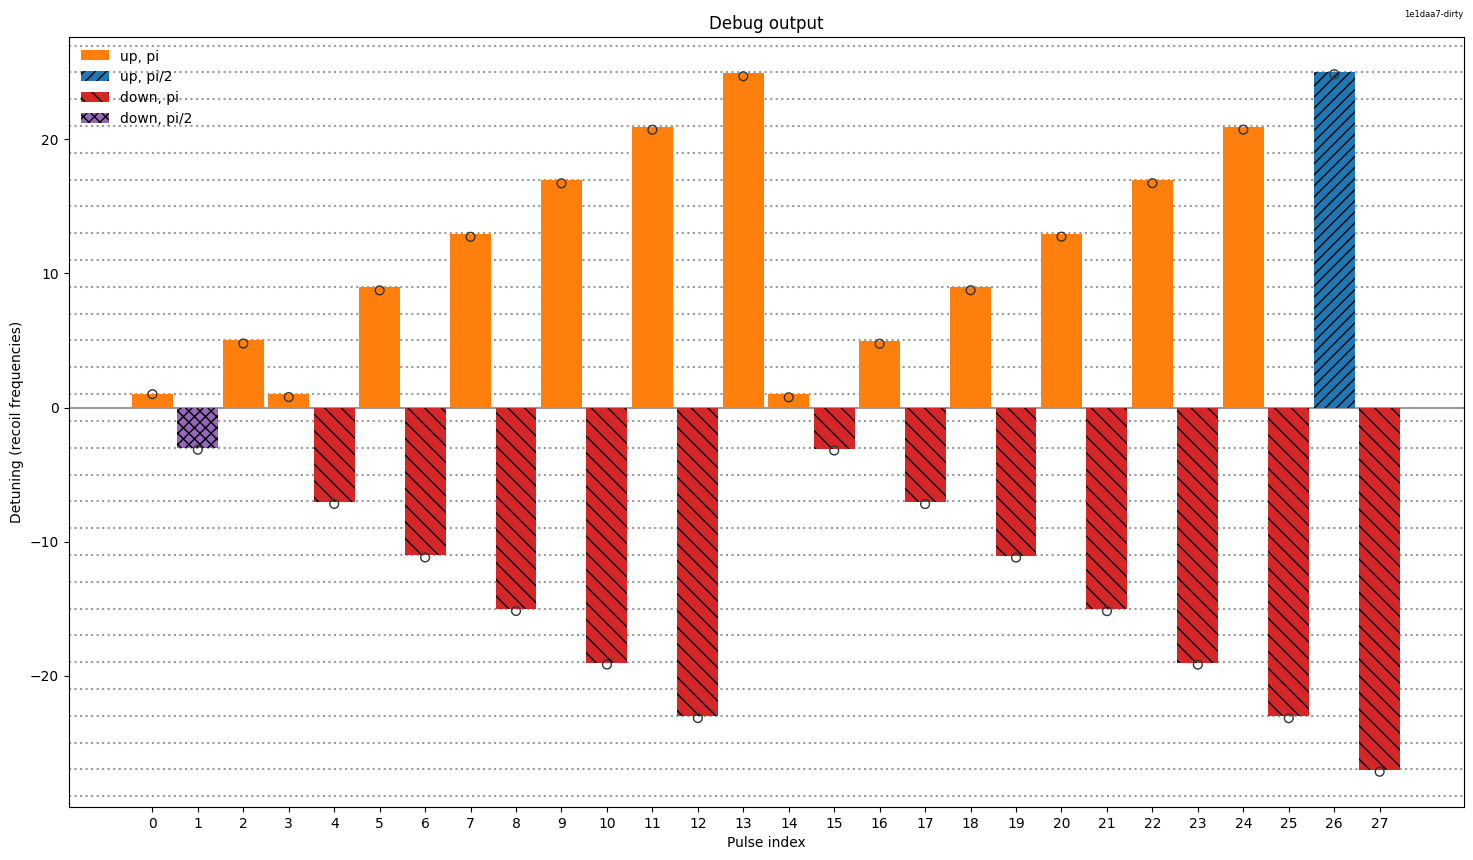

In [15]:
plot_lab_pulse_sequence(sequence, plot_corrected=True)
plt.title("Debug output")
vs.tag_plot(small=True);

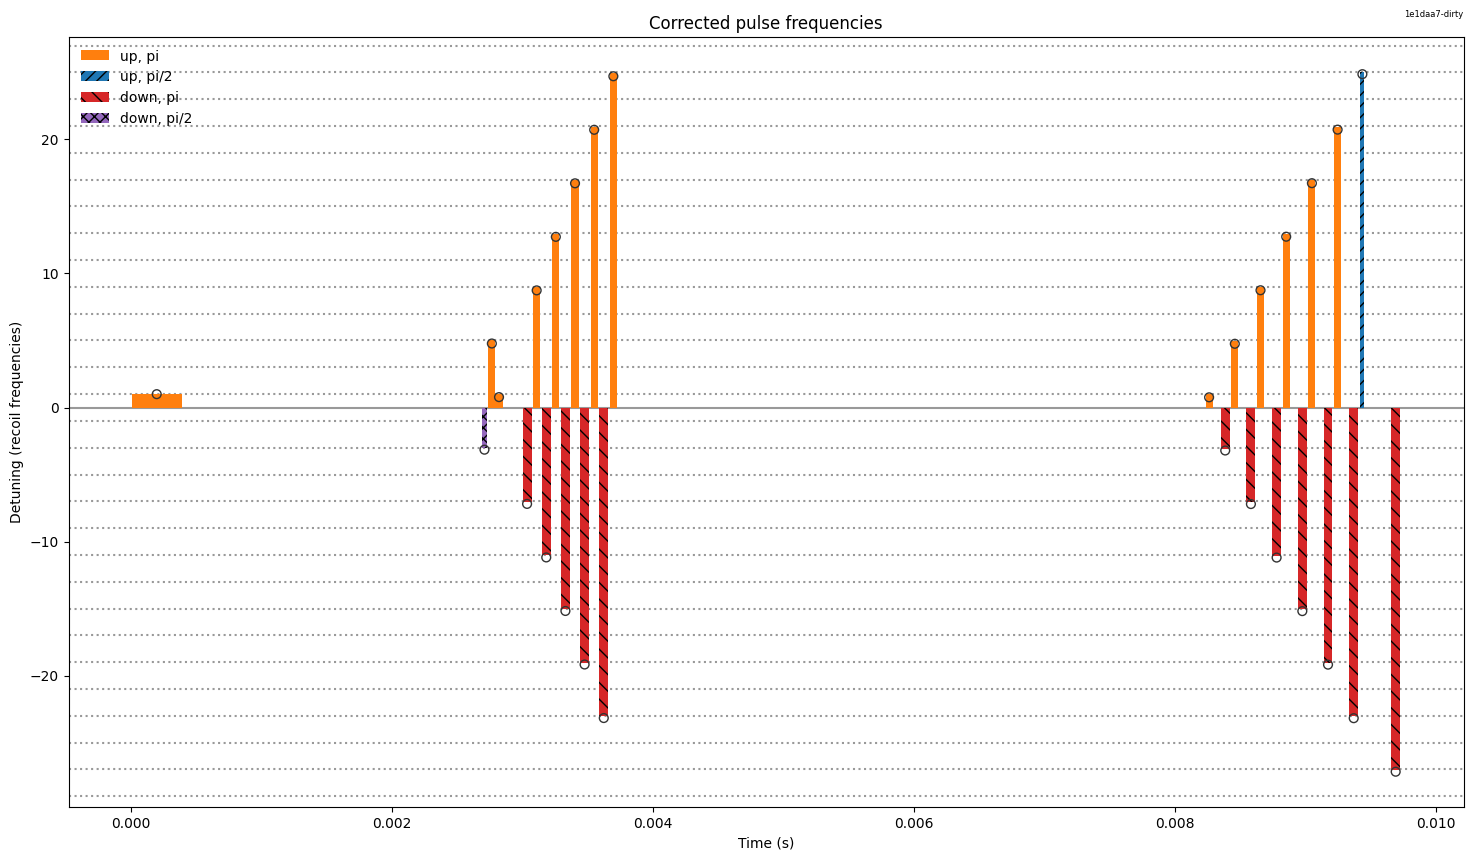

In [16]:
plot_lab_pulse_sequence(sequence, plot_corrected=True, plot_by_timestamp=True)
plt.title("Corrected pulse frequencies")
vs.tag_plot(small=True);

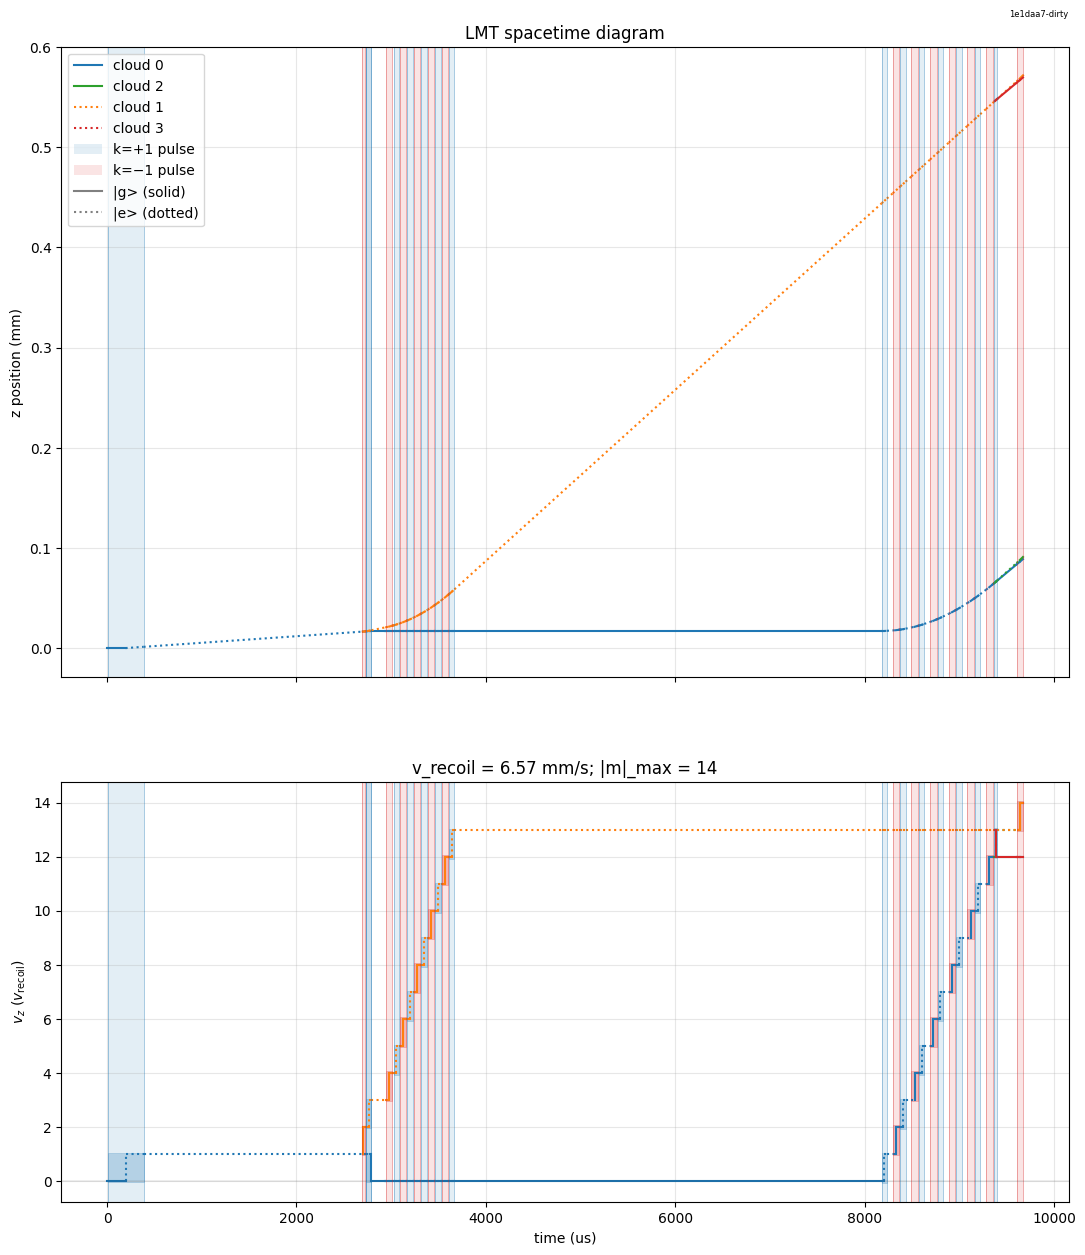

In [17]:
seq.compute_spacetime_trajectory(sequence, plot=True, max_branches=20)
vs.tag_plot(small=True);

In [18]:
# Apply a hacky correction - round each pulse to the nearest corrected integer number of recoils
import dataclasses

bodged_sequence = []
for event in sequence:
    if not isinstance(event, seq.Pulse):
        bodged_sequence.append(event)
        continue

    probe_shift_hz = (
        event.probe_shift_coefficient * event.effective_stark_rabi_frequency**2
    )

    closest_integer = int(
        round((event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ)
    )

    # Re-add the probe shift so that the EFFECTIVE detuning (the sim subtracts
    # the shift again during the pulse) lands exactly on the recoil ladder.
    new_pulse = dataclasses.replace(
        event,
        detuning_hz=closest_integer * sim.RECOIL_FREQUENCY_HZ + probe_shift_hz,
    )
    bodged_sequence.append(new_pulse)


([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(4.936000000000001e-06), np.float64(0.000384936), np.float64(0.0026903989999999996), np.float64(0.0027243989999999997), np.float64(0.0027365429999999997), np.float64(0.0027915419999999997), np.float64(0.0027915419999999997), np.float64(0.002936542), np.float64(0.002945087), np.float64(0.003013087), np.float64(0.0030250859999999997), np.float64(0.0030800849999999998), np.float64(0.0030920849999999996), np.float64(0.0031600849999999995), np.float64(0.003172084), np.float64(0.003227083), np.float64(0.003239083), np.float64(0.0033070829999999997), np.float64(0.0033190819999999997), np.float64(0.0033740809999999997), np.float64(0.003386081), np.float64(0.003454081), np.float64(0.00346608), np.float64(0.003521079), np.float64(0.0035330789999999997), np.float64(0.0036010789999999997), np.float64(0.0036130779999999996), np.float64(0.0036680769999999996), np.float64(0.008180077000000001), np.float64(0.008235076000000001), np.fl

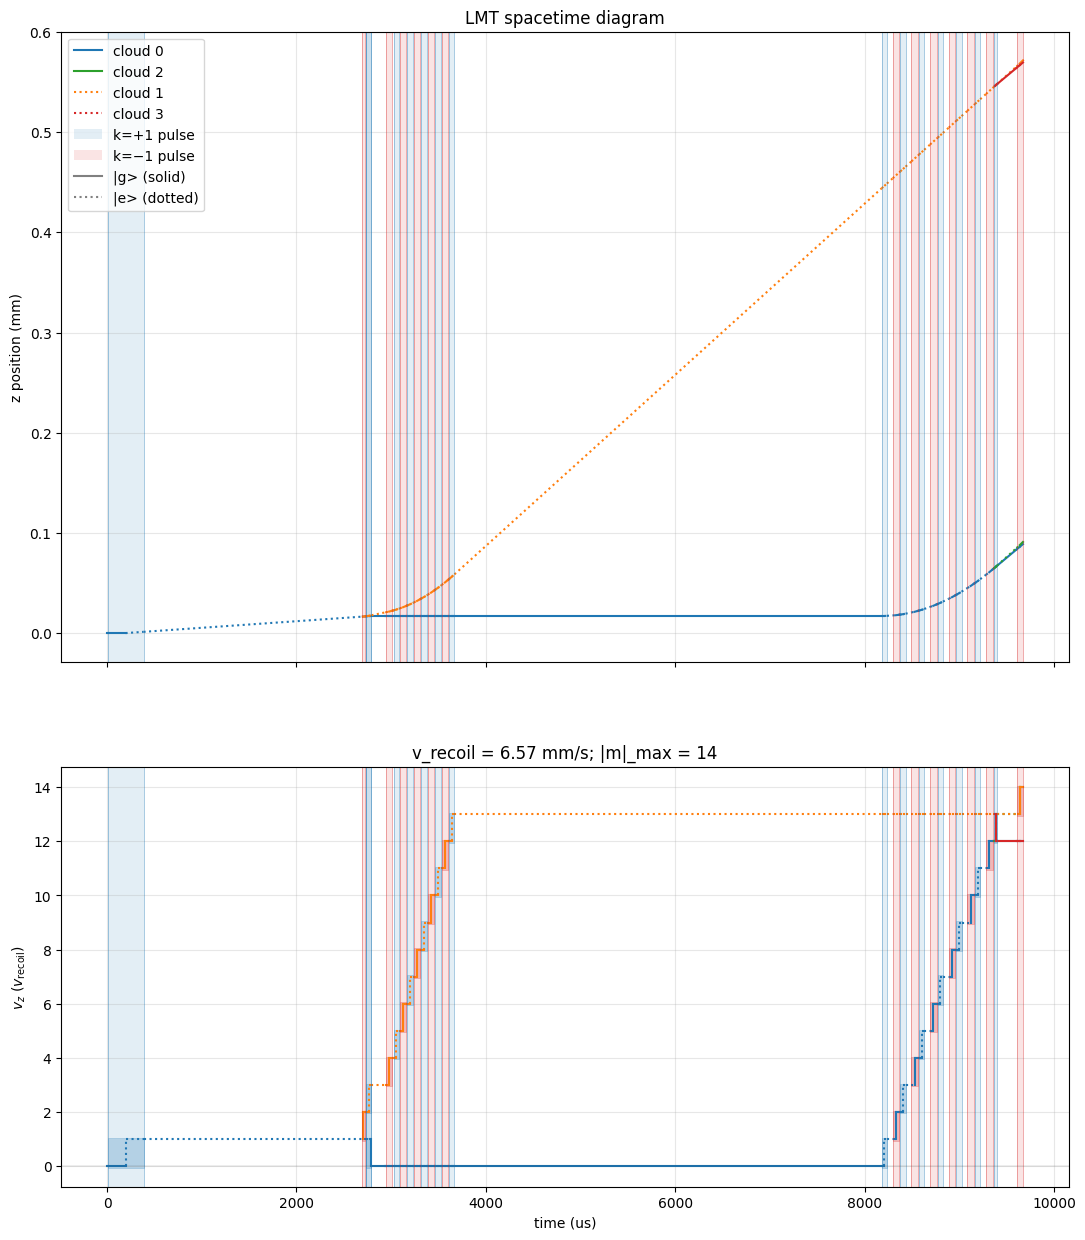

In [19]:
seq.compute_spacetime_trajectory(bodged_sequence, plot=True, max_branches=20)